In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

sys.path.append(str(Path('..') / 'src'))
from config import CH

def query_to_df(sql):
    rows, cols = CH.execute(sql, with_column_types=True)
    return pd.DataFrame(rows, columns=[c[0] for c in cols])

In [2]:
print('=== a) Top 10 películas más rentadas ===')
df_a = query_to_df('''
    SELECT
        f.title                        AS pelicula,
        f.category                     AS categoria,
        f.rating                       AS clasificacion,
        count()                        AS total_rentas,
        round(sum(fr.amount), 2)       AS ingresos_totales
    FROM gold.fact_rental fr
    JOIN gold.dim_film f ON fr.film_key = f.film_key
    GROUP BY f.title, f.category, f.rating
    ORDER BY total_rentas DESC
    LIMIT 10
''')
print(df_a.to_string(index=False))

=== a) Top 10 películas más rentadas ===
           pelicula categoria clasificacion  total_rentas ingresos_totales
 BUCKET BROTHERHOOD    Travel            PG            34           180.66
   ROCKETEER MOTHER   Foreign         PG-13            33           116.67
     FORWARD TEMPLE     Games         NC-17            32           128.68
      SCALAWAG DUCK     Music         NC-17            32           172.68
RIDGEMONT SUBMARINE       New         PG-13            32           130.68
     GRIT CLOCKWORK     Games            PG            32           110.68
     JUGGLER HARDLY Animation         PG-13            32            96.68
       ROBBERS JOON  Children         PG-13            31           105.69
    RUSH GOODFELLAS    Family            PG            31            88.69
  GOODFELLAS SALUTE    Sci-Fi            PG            31           209.69


In [3]:
print('=== b) País donde más se rentan películas ===')
df_b = query_to_df('''
    SELECT
        c.country                      AS pais,
        count()                        AS total_rentas,
        round(sum(fr.amount), 2)       AS ingresos_totales
    FROM gold.fact_rental fr
    JOIN gold.dim_customer c ON fr.customer_key = c.customer_key
    GROUP BY c.country
    ORDER BY total_rentas DESC
    LIMIT 10
''')
print(df_b.to_string(index=False))

=== b) País donde más se rentan películas ===
              pais  total_rentas ingresos_totales
             India          1572          6628.28
             China          1426          5798.74
     United States           968          4110.32
             Japan           825          3470.75
            Mexico           796          3307.04
            Brazil           748          3200.52
Russian Federation           713          3045.87
       Philippines           568          2381.32
            Turkey           388          1662.12
         Indonesia           367          1510.33


In [4]:
print('=== c) Montos totales pagados por cliente (Top 20) ===')
df_c = query_to_df('''
    SELECT
        c.customer_key                 AS id_cliente,
        c.full_name                    AS cliente,
        c.country                      AS pais,
        count()                        AS total_rentas,
        round(sum(fr.amount), 2)       AS monto_total_pagado
    FROM gold.fact_rental fr
    JOIN gold.dim_customer c ON fr.customer_key = c.customer_key
    GROUP BY c.customer_key, c.full_name, c.country
    ORDER BY monto_total_pagado DESC
    LIMIT 20
''')
print(df_c.to_string(index=False))

=== c) Montos totales pagados por cliente (Top 20) ===
 id_cliente        cliente               pais  total_rentas monto_total_pagado
        526      KARL SEAL      United States            45             221.55
        148   ELEANOR HUNT            Réunion            46             216.54
        144     CLARA SHAW            Belarus            42             195.58
        178  MARION SNYDER             Brazil            39             194.61
        137 RHONDA KENNEDY        Netherlands            39             194.61
        459  TOMMY COLLAZO               Iran            38             186.62
        469    WESLEY BULL              Spain            40              177.6
        468       TIM CARY              India            39             175.61
        236    MARCIA DEAN        Philippines            42             175.58
        181    ANA BRADLEY      United States            34             174.66
        176   JUNE CARROLL            Algeria            37             173.

In [5]:
print('=== d) Top 10 actores con más rentas ===')
df_d = query_to_df('''
    SELECT
        a.full_name                    AS actor,
        count()                        AS total_rentas,
        round(sum(fr.amount), 2)       AS ingresos_generados
    FROM gold.fact_rental fr
    JOIN bronze.raw_film_actor fa ON fr.film_key  = fa.film_id
    JOIN gold.dim_actor        a  ON fa.actor_id  = a.actor_key
    GROUP BY a.full_name
    ORDER BY total_rentas DESC
    LIMIT 10
''')
print(df_d.to_string(index=False))

=== d) Top 10 actores con más rentas ===
             actor  total_rentas ingresos_generados
       SUSAN DAVIS           825            3538.74
    GINA DEGENERES           753            3442.49
    MATTHEW CARREY           678            2742.19
       MARY KEITEL           674            2689.25
ANGELA WITHERSPOON           654            2614.46
       WALTER TORN           640            2620.62
       HENRY BERRY           612            2602.88
       JAYNE NOLTE           611            2400.86
        VAL BOLGER           605            2253.95
     SANDRA KILMER           604            2485.96


=== e) Serie temporal de montos cobrados por mes ===


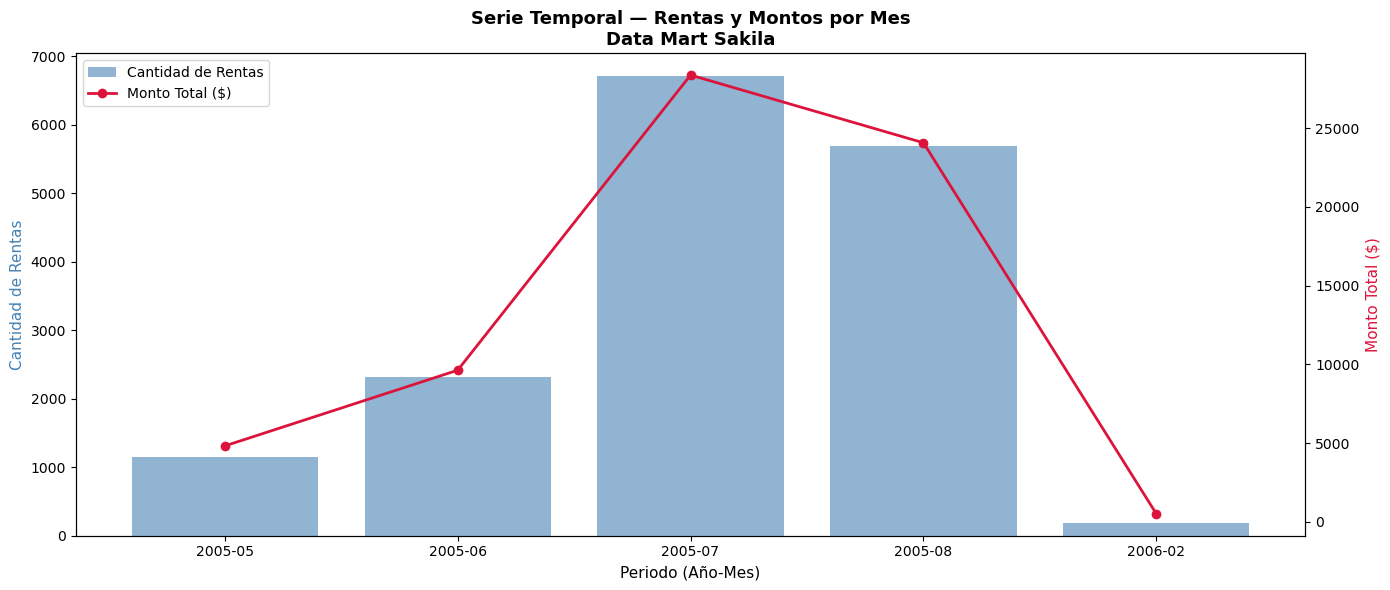

Gráfico guardado en outputs/serie_temporal_sakila.png


In [6]:
print('=== e) Serie temporal de montos cobrados por mes ===')
df_e = query_to_df('''
    SELECT
        d.year                         AS anio,
        d.month                        AS mes,
        d.month_name                   AS nombre_mes,
        count()                        AS total_rentas,
        round(sum(fr.amount), 2)       AS monto_total
    FROM gold.fact_rental fr
    JOIN gold.dim_date d ON fr.date_key = d.date_key
    GROUP BY d.year, d.month, d.month_name
    ORDER BY d.year, d.month
''')

df_e['periodo']     = df_e['anio'].astype(str) + '-' + df_e['mes'].astype(str).str.zfill(2)
df_e['monto_total'] = df_e['monto_total'].astype(float)

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.bar(df_e['periodo'], df_e['total_rentas'],
        color='steelblue', alpha=0.6, label='Cantidad de Rentas')
ax2.plot(df_e['periodo'], df_e['monto_total'],
         color='crimson', marker='o', linewidth=2, label='Monto Total ($)')

ax1.set_xlabel('Periodo (Año-Mes)', fontsize=11)
ax1.set_ylabel('Cantidad de Rentas', color='steelblue', fontsize=11)
ax2.set_ylabel('Monto Total ($)', color='crimson', fontsize=11)
plt.title('Serie Temporal — Rentas y Montos por Mes\nData Mart Sakila', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../outputs/serie_temporal_sakila.png', dpi=150)
plt.show()
print('Gráfico guardado en outputs/serie_temporal_sakila.png')